In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO, Entrez
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF"

# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# 3 samples are duplicated in here wow
MIC_ML_orig = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv")
MIC_ML = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/MIC_ML/data_with_paths.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

solo_results = pd.read_csv("/home/sak0914/who-analysis/results/SOLO_Final_Aug2023.csv", header=[1])

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

In [18]:
dropped_features_df = pd.DataFrame(columns = ['Drug', "Pheno", 'Model', 'Type', 'Count'])
i = 0

for drug in os.listdir("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue"):

    for pheno in ['WHO', 'ALL']:

        dir_name = f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/BINARY/tiers=1/phenos={pheno}"

        for subdir in os.listdir(dir_name):
            if os.path.isdir(f"{dir_name}/{subdir}"):

                for dropped_feat_file in os.listdir(f"{dir_name}/{subdir}/dropped_features"):
                    num_feat = subprocess.Popen(f"wc -l {dir_name}/{subdir}/dropped_features/{dropped_feat_file}", shell=True, encoding='utf-8', stdout=subprocess.PIPE)
                    num_feat = num_feat.communicate()[0]
                    dropped_features_df.loc[i, :] = [drug, pheno, subdir, dropped_feat_file.split(".")[0], int(num_feat.split("\t")[0].split(" ")[0])]
                    i += 1

In [44]:
drug = "Streptomycin"
dropped_features_df.query("Drug==@drug & Model=='dropAF_noSyn_unpooled' & Type != 'no_signal'").sort_values(['Pheno', "Type"], ascending=[False, False])

,Drug,Pheno,Model,Type,Count
35,Streptomycin,WHO,dropAF_noSyn_unpooled,isolates_with_amb,227
33,Streptomycin,WHO,dropAF_noSyn_unpooled,isolates_dropped,64
44,Streptomycin,ALL,dropAF_noSyn_unpooled,isolates_with_amb,246
42,Streptomycin,ALL,dropAF_noSyn_unpooled,isolates_dropped,78


In [45]:
model_matrix_WHO = pd.read_pickle(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/BINARY/tiers=1/phenos=WHO/dropAF_noSyn_unpooled/model_matrix.pkl")

model_matrix_ALL = pd.read_pickle(f"/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/{drug}/BINARY/tiers=1/phenos=ALL/dropAF_noSyn_unpooled/model_matrix.pkl")

print(model_matrix_WHO.shape, model_matrix_ALL.shape)

(18151, 1273) (24298, 1516)


In [3]:
# for model_path in os.listdir('/n/data1/hms/dbmi/farhat/Sanjana/CNN_results'):
#     if os.path.isfile(os.path.join('/n/data1/hms/dbmi/farhat/Sanjana/CNN_results', model_path, 'ridge', 'model_feature_names.txt')):
#         os.rename(os.path.join('/n/data1/hms/dbmi/farhat/Sanjana/CNN_results', model_path, 'ridge', 'model_feature_names.txt'), os.path.join('/n/data1/hms/dbmi/farhat/Sanjana/CNN_results', model_path, 'ridge', 'model_features.txt'))

In [2]:
files_lst = os.listdir("/n/scratch3/users/s/sak0914/ncbi_download")

# 1. Compare MIC Distributions Between the Training Dataset and MIC-ML

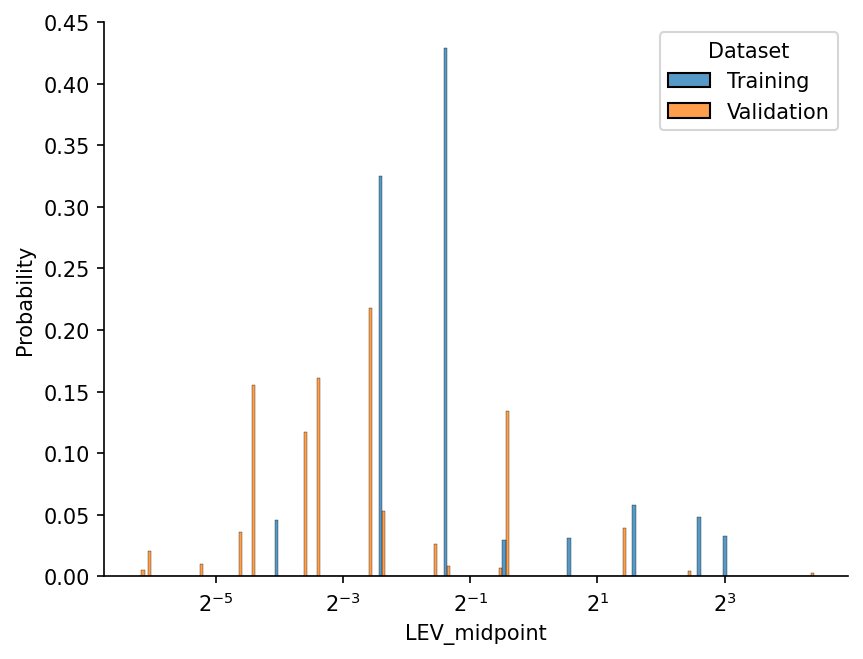

In [29]:
drug = "LEV"
df_train = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
df_val = pd.read_csv(os.path.join(data_dir, drug, "validation_data_for_model.csv"))
df_train["Dataset"] = "Training"
df_val["Dataset"] = "Validation"

# just out of curiosity if we didn't normalize MICs to 7H10
# df_val[[f"{drug}_midpoint_original", "Dataset"]].rename(columns={f"{drug}_midpoint_original": f"{drug}_midpoint"})

# _midpoint column has been normalized to 7H10, but lower and upper bounds have not. They are named _original
df_combined = pd.concat([df_train[[f"{drug}_midpoint", "Dataset"]], df_val[[f"{drug}_midpoint", "Dataset"]]], axis=0)
df_combined["log2_MIC"] = np.log2(df_combined[f"{drug}_midpoint"])

sns.histplot(data=df_combined, x=f"{drug}_midpoint", hue="Dataset", multiple="dodge", common_norm=False, stat="probability", log_scale=2)
sns.despine()
plt.show()

In [45]:
# not scale-invariant
_, pval_parametric = st.ttest_ind(df_combined.query("Dataset=='Training'")[f"{drug}_midpoint"], df_combined.query("Dataset=='Validation'")[f"{drug}_midpoint"], equal_var=False, alternative='less')

# scale-invariant
_, pval_nonparametric = st.ranksums(df_combined.query("Dataset=='Training'")[f"{drug}_midpoint"], df_combined.query("Dataset=='Validation'")[f"{drug}_midpoint"], alternative='less')

print(f"Welch's t-test: {pval_parametric}")
print(f"Wilcoxon rank-sum test: {pval_nonparametric}")

Welch's t-test: 1.8050400828616613e-62
Wilcoxon rank-sum test: 2.496614556066727e-97


In [33]:
drug = "RIF"
path = f"{drug}_rpoABC"

df_train = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
df_val = pd.read_csv(os.path.join(data_dir, drug, "validation_data_for_model.csv"))
print(df_val.shape)

df_Reg_pred = pd.read_csv(os.path.join(results_path, path, "validation/Reg_predictions.csv"))
df_CNN_pred = pd.read_csv(os.path.join(results_path, path, "validation/CNN_predictions.csv"))

# LEV_isolate_variants = pd.read_csv(os.path.join(data_dir, drug, "isolate_variants.csv.gz"), compression="gzip")
RIF_isolate_variants = pd.read_csv(os.path.join(data_dir, drug, "isolate_variants_fixed_annot.csv"))

(1324, 15)


In [24]:
def combine_with_bounds(df_pred, df_val, drug, cc):

    df_combined = df_pred.merge(df_val[["ROLLINGDB_ID", f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound", f"{drug}_lower_bound_original", f"{drug}_midpoint_original", f"{drug}_upper_bound_original"]], left_on="Isolate", right_on="ROLLINGDB_ID")
    df_combined["y_pred_exp"] = np.exp2(df_combined["y_pred"])
    
    df_combined.loc[(df_combined["y_pred_exp"] < df_combined[f"{drug}_lower_bound"]) | (df_combined["y_pred_exp"] > df_combined[f"{drug}_upper_bound"]), "compute_error"] = 1
        
    df_combined.loc[(df_combined["y_pred_exp"] >= df_combined[f"{drug}_lower_bound"] / 2) & (df_combined["y_pred_exp"] <= df_combined[f"{drug}_upper_bound"] * 2), "within_doubling"] = 1

    df_combined["compute_error"] = df_combined["compute_error"].fillna(0).astype(int)
    df_combined["within_doubling"] = df_combined["within_doubling"].fillna(0).astype(int)

    df_combined["pred_R"] = (df_combined["y_pred_exp"] >= cc).fillna(0).astype(int)
    df_combined["test_R"] = (np.exp2(df_combined["y_test"]) >= cc).fillna(0).astype(int)
    
    return df_combined

In [68]:
def plot_catplot(model_path, variable_lst, kind="bar", excludeCat1LowMIC=False, lower_bounds=None, upper_bounds=None, 
                 label_padding=0, sharey=False, percent=False, sigfig=2, saveName=None
                ):

    if excludeCat1LowMIC:
        file_suffix = "_noCat1LowMIC"
    else:
        file_suffix = ""
        
    CNN_stats = pd.read_csv(os.path.join(results_path, model_path, "validation", f"CNN_stats{file_suffix}.csv"))
    Reg_stats = pd.read_csv(os.path.join(results_path, model_path, "validation", f"Reg_stats{file_suffix}.csv"))                    
    catalog_stats = pd.read_csv(os.path.join(results_path, model_path.replace("_lineage", ""), "validation", f"catalog_stats{file_suffix}.csv"))

    if excludeCat1LowMIC:
        catalog_stats_test = pd.read_csv(os.path.join(results_path, model_path.replace("_lineage", ""), "validation", f"catalog_stats.csv")).query("Dataset=='Test'")
        catalog_stats = pd.concat([catalog_stats, catalog_stats_test], axis=0)
        del catalog_stats_test

    df = pd.concat([CNN_stats, Reg_stats, catalog_stats], axis=0).query("Dataset != 'Train'") #CNN_lineage_stats, Reg_lineage_stats, catalog_stats], axis=0)
    df['Without_doubling'] = 1 - df['Within_doubling']

    binary_metrics_for_plotting = df.melt(id_vars=['Model', 'Dataset', 'CV'])
    binary_metrics_for_plotting["Model"] = binary_metrics_for_plotting["Model"].replace("Reg", "Regression").replace("LinReg", "Regression")

    if percent:
        binary_metrics_for_plotting["value"] *= 100
    
    binary_metrics_for_plotting = binary_metrics_for_plotting.query("CV > 0 & variable in @variable_lst").dropna(axis=0)                    
    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
            
    if binary_metrics_for_plotting["Model"].nunique() == 3:
        hue_order = ["Catalog", "Regression", "CNN"]
        color_dict = dict(zip(["CNN", "Regression", "Catalog"], palette[:len(binary_metrics_for_plotting["Model"].unique())]))
    else:
        hue_order = ["Regression", "CNN"]
        color_dict = dict(zip(["CNN", "Regression"], palette[:len(binary_metrics_for_plotting["Model"].unique())]))

    if kind == "strip":
        
        g = sns.catplot(data=binary_metrics_for_plotting, 
                        x="Dataset", 
                        y="value", 
                        hue="Model", 
                        col="variable", 
                        col_order=variable_lst,
                        col_wrap=3,
                        hue_order=hue_order,
                        kind="strip", 
                        aspect=0.8, 
                        height=3.5, 
                        dodge=True,
                        palette=color_dict,
                        linewidth=0.5,
                        sharex=False,
                        sharey=sharey,
                       )

    elif kind == "bar":
        g = sns.catplot(data=binary_metrics_for_plotting, 
                        x="Dataset", 
                        y="value", 
                        hue="Model", 
                        col="variable", 
                        col_order=variable_lst,
                        col_wrap=3,
                        hue_order=hue_order,
                        kind="bar", 
                        aspect=0.8, 
                        height=3.5, 
                        dodge=True,
                        palette=color_dict,
                        errorbar=("pi", 95),
                        edgecolor="black",
                        linewidth=0.5,
                        errwidth=0.75,
                        capsize=0.05,
                        sharex=False,
                        sharey=sharey,
                       )

    for i, ax in enumerate(g.axes.flat):
        ax.set_xlabel("")
        ax.set_ylabel("")

        if lower_bounds is not None:
            if lower_bounds[i] is not None:
                ax.set_ylim(bottom=lower_bounds[i])

        if upper_bounds is not None:
            if upper_bounds[i] is not None:
                ax.set_ylim(top=upper_bounds[i])
        
        if kind == "bar":
            for container in ax.containers:
                # larger font when there are fewer bars
                if len(hue_order) == 2:
                    weight='normal'
                    size = 9
                else:
                    size = 7
                    weight='light'
                # Add labels to the bars
                for p in ax.patches:
                    ax.annotate(f'{p.get_height():.{sigfig}f}', (p.get_x() + p.get_width() / 2, p.get_height() * 0.4), ha='center', va='center', fontsize=size, fontweight=weight, color='black')

    g.set_titles(template='{col_name}\n')
    g.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

    return binary_metrics_for_plotting

# Sublineages between Train and Validation Sets

In [5]:
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv", index_col=[0])
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

In [12]:
drug = "MXF"
df_train = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
df_val = pd.read_csv(os.path.join(data_dir, drug, "validation_data_for_model.csv"))
print(df_train.shape, df_val.shape)

df_val = df_val.merge(lineages, left_on='ROLLINGDB_ID', right_index=True)
print(df_val.shape)

(7354, 19) (1076, 16)
(1076, 22)


In [16]:
df_val.query("Coll2014.str.contains(',')")

,ROLLINGDB_ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF_quality,MXF_lower_bound_original,MXF_midpoint_original,...,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,WHO_Cat1_mutation,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage
411,TRL0081287,South Africa,NICD,NaN,NaN,Not specified,Broth micro-dilution (BMD),NaN,0.030,0.0450,...,0.0150,0.022500,0.03000,0,"4.3,2.2.1",2.2.1.1.1,"beijing,bcg,canetti,lam,mungi","lin2.2.1,asian_african_2",NaN,4
589,TRL0116064,South Africa,NICD,NaN,NaN,Not specified,Broth micro-dilution (BMD),NaN,0.030,0.0450,...,0.0150,0.022500,0.03000,0,"2.2.1,4.3.4","2.2.1.1.1,4.2.1.2.1.1","beijing,lam,mungi",lin2.2.1,NaN,2
909,C125,NaN,CASS,NaN,NaN,Not specified,MYCOTB,NaN,1.500,1.7500,...,0.3750,0.437500,0.50000,1,"2.2.2,4.3.2.1","2.2.2,4.2.1.2.1.1.i1","beijing,lam","asia_ancestral_1,lin2.2",4.3/LAM,2
1013,C309,NaN,CASS,NaN,NaN,Not specified,MYCOTB,NaN,0.094,0.1095,...,0.0235,0.027375,0.03125,0,"4.3.4.2.1,4.1.1.3","4.2.1.2.1.1.i3.1,4.1.i1.2.1","lam,xtype",NaN,4.3/LAM,4
1045,C362,NaN,CASS,NaN,NaN,Not specified,MYCOTB,NaN,0.094,0.1095,...,0.0235,0.027375,0.03125,0,"4.1.2.1,2.2.1.1","4.1.i1.1.1.1,2.2.1.1.1","beijing,haarlem","lin2.2.1,pacific_RD150",4.1.2/Haarlem,4


In [73]:
RIF_pred_CNN = pd.read_csv(os.path.join(results_path, "RIF_rpoABC", "validation", "CNN_predictions.csv"))
RIF_pred_Ridge = pd.read_csv(os.path.join(results_path, "RIF_rpoABC", "validation", "Reg_predictions.csv"))

In [78]:
RIF_pred_CNN.query("compute_error==1")

,Isolate,y_test,lower,upper,y_pred,y_pred_exp,within_doubling,compute_error
0,20542,-1.415037,0.2500,0.500,-4.039944,0.06,0,1
1,23768,0.584963,0.5000,2.500,3.484618,11.19,0,1
2,24304,-3.415037,0.0625,0.125,-4.038473,0.06,1,1
3,26243,-3.415037,0.0625,0.125,-4.120211,0.06,1,1
4,23886,0.584963,0.5000,2.500,-4.129191,0.06,0,1
...,...,...,...,...,...,...,...,...
1310,C476,1.584963,2.0000,4.000,5.478466,44.58,0,1
1311,C478,-6.058894,0.0000,0.030,-4.039944,0.06,1,1
1312,C480,1.584963,2.0000,4.000,5.482157,44.70,0,1
1313,C485,-6.058894,0.0000,0.030,-4.120211,0.06,1,1


In [93]:
def boundedLoss_Reg(y_pred, y_true, lower_bounds, upper_bounds, loss_type="L1"):
    '''
    This function is used to select the regularization strength of a Regression model. It is the Regression analog
    of boundedLoss_CNN
    
    y_test and y_pred are log2-transformed. lower_bounds and upper_bounds are NOT
    loss_type is L1 or L2, specifying whether to return the MAE or MSE
    '''

    # add a tiny amount so they can be log-transformed, then log-transform
    lower_bounds[lower_bounds==0] += 1e-6
    lower_bounds = np.log2(lower_bounds)
    upper_bounds = np.log2(upper_bounds)

    # determine whether to compute error from the bounds or if the error is 0. 
    bound_to_compute_error = np.clip(y_pred, lower_bounds, upper_bounds)

    # compute the errors first using the log-MICs, based on the desired loss type
    # if you want to compute error relative to the midpoint, replace bound_to_compute_error with y_true
    if loss_type == "L1":
        errors = np.abs(bound_to_compute_error - y_pred)
    elif loss_type == "L2":
        errors = np.exp2(bound_to_compute_error - y_pred)
    else:
        raise RuntimeError(f"{loss_type} is not a valid loss function type")

    # because we used np.clip above, the value in the errors array for points predicted within the MIC bin will be 0, so just take the simple mean
    return errors

In [101]:
Reg_errors = boundedLoss_Reg(RIF_pred_Ridge['y_pred'], RIF_pred_Ridge['y_test'], RIF_pred_Ridge['lower'], RIF_pred_Ridge['upper'], loss_type="L1")
RIF_pred_Ridge["error"] = Reg_errors

In [99]:
len(Reg_errors), len(CNN_errors)

(1315, 1315)

In [103]:
CNN_errors = boundedLoss_Reg(RIF_pred_CNN['y_pred'], RIF_pred_CNN['y_test'], RIF_pred_CNN['lower'], RIF_pred_CNN['upper'], loss_type="L1")
RIF_pred_CNN["error"] = CNN_errors

In [115]:
np.mean(RIF_pred_CNN['error'])

1.3731733704511841

In [116]:
np.mean(RIF_pred_Ridge['error'])

1.3946777750842574

In [117]:
RIF_pred_CNN.query("compute_error==1").sort_values("lower")

,Isolate,y_test,lower,upper,y_pred,y_pred_exp,within_doubling,compute_error,error
1314,C486,-6.058894,0.000001,0.03,-4.120211,0.06,1,1,0.938683
1155,C166,-6.058894,0.000001,0.03,-4.129191,0.06,1,1,0.929702
1154,C165,-6.058894,0.000001,0.03,-4.129191,0.06,1,1,0.929702
1280,C361,-6.058894,0.000001,0.03,-4.120272,0.06,1,1,0.938622
1191,C227,-6.058894,0.000001,0.03,-4.129191,0.06,1,1,0.929702
...,...,...,...,...,...,...,...,...,...
616,TRL0081287,5.584963,32.000000,64.00,-4.176498,0.06,0,1,9.176498
619,TRL0084676,5.584963,32.000000,64.00,6.787508,110.47,1,1,0.787508
620,TRL0085451,5.584963,32.000000,64.00,6.045115,66.03,1,1,0.045115
667,TRL0113325,5.584963,32.000000,64.00,0.384067,1.31,0,1,4.615933


In [118]:
RIF_pred_Ridge.query("compute_error==1").sort_values("lower")

,Isolate,y_test,lower,upper,y_pred,y_pred_exp,within_doubling,compute_error,error
1314,C486,-6.058894,0.000001,0.03,-3.715749,0.08,0,1,1.343145
88,GA016-52,-3.000000,0.000001,0.25,-0.962230,0.51,0,1,1.037770
1191,C227,-6.058894,0.000001,0.03,-4.351759,0.05,1,1,0.707135
106,GA569-315,-3.000000,0.000001,0.25,2.951324,7.73,0,1,4.951324
1155,C166,-6.058894,0.000001,0.03,-4.351759,0.05,1,1,0.707135
...,...,...,...,...,...,...,...,...,...
717,TRL0114661,5.584963,32.000000,64.00,2.703318,6.51,0,1,2.296682
718,TRL0114666,5.584963,32.000000,64.00,2.690278,6.45,0,1,2.309722
719,TRL0114667,5.584963,32.000000,64.00,2.398817,5.27,0,1,2.601183
712,TRL0114585,5.584963,32.000000,64.00,2.164742,4.48,0,1,2.835258


# Model Comparisons

# Rifampicin

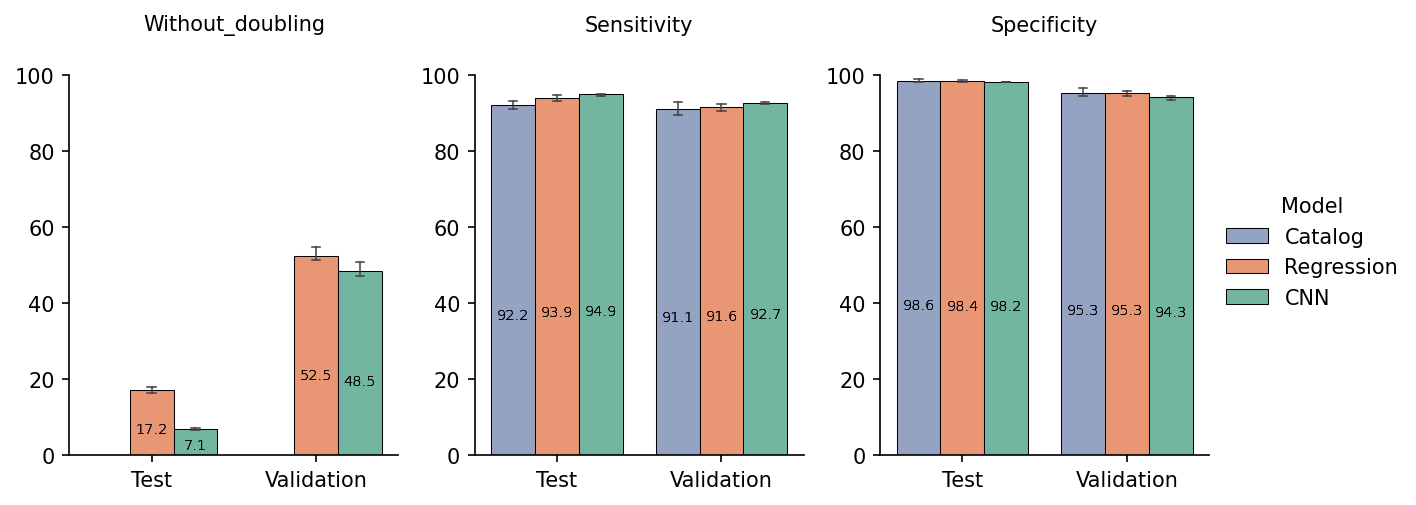

In [89]:
model_path = "RIF_rpoABC"
variable_lst = ["Without_doubling", "Sensitivity", "Specificity"]

RIF_results = plot_catplot(model_path, variable_lst, kind="bar", excludeCat1LowMIC=False, lower_bounds=[0, 0, 0], upper_bounds=[100, 100, 100], 
                                 label_padding=0, sharey=False, percent=True, sigfig=1, saveName=None
                                )

# Moxifloxacin

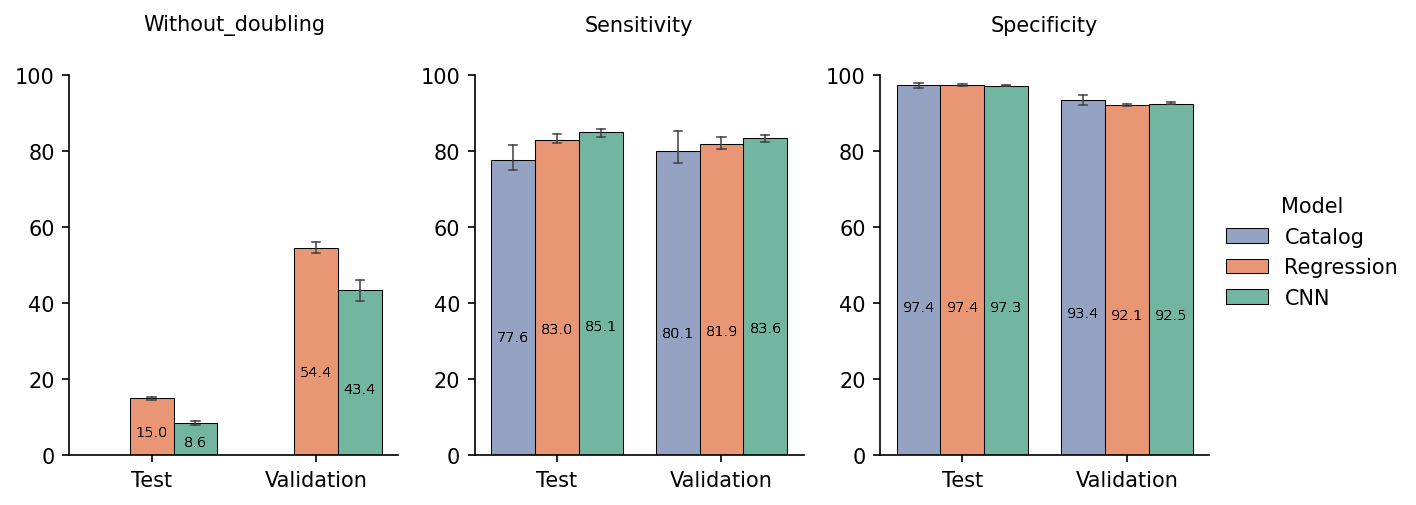

In [61]:
model_path = "MXF_gyrBA"
variable_lst = ["Without_doubling", "Sensitivity", "Specificity"]

MXF_results = plot_catplot(model_path, variable_lst, kind="bar", excludeCat1LowMIC=False, lower_bounds=[0, 0, 0], upper_bounds=[100, 100, 100], 
                                 label_padding=0, sharey=False, percent=True, sigfig=1, saveName=None
                                )

# Levofloxacin

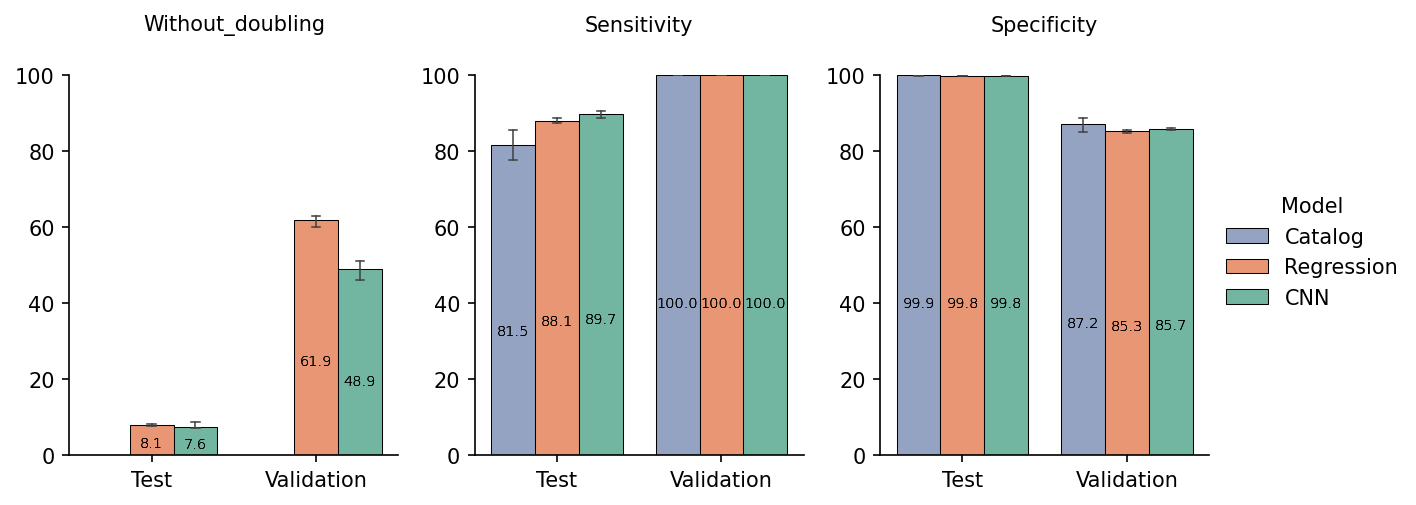

In [66]:
model_path = "LEV_gyrBA"
variable_lst = ["Without_doubling", "Sensitivity", "Specificity"]

LEV_results = plot_catplot(model_path, variable_lst, kind="bar", excludeCat1LowMIC=False, lower_bounds=[0, 0, 0], upper_bounds=[100, 100, 100], 
                                 label_padding=0, sharey=False, percent=True, sigfig=1, saveName=None
                                )

In [27]:
df_val = pd.read_csv(os.path.join(data_dir, "RIF", "validation_data_for_model.csv"))

In [29]:
df_val.DB_OF_ORIGIN.value_counts()

DB_OF_ORIGIN
NICD             359
JATA-KIT         330
CASS             262
Wadsworth        203
EXIT-RIF          74
JATA-Mongolia     36
Cox               33
NSW               18
Name: count, dtype: int64

In [88]:
os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/MIC-ML_output")

['NICD',
 'JATA-KIT',
 'Gandhi',
 'JATA-MONGOLIA',
 'NSW',
 'Wadsworth',
 'logs',
 'CASS1',
 'EXIT-RIF',
 'Cox',
 'kreiswirth',
 'Helencox',
 'Lizma']

In [51]:
data = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/sources/Kreiswirth_INH_RIF_MIC.xlsx", sheet_name=None)['Sheet1']

In [31]:
df_val.MEDIA.value_counts()

MEDIA
MGIT960/MGIT7h9               473
Broth micro-dilution (BMD)    359
MYCOTB                        262
UKMYC (Cryptic sensititre)    203
NSW sensititre plate           18
Name: count, dtype: int64

In [45]:
df_pred.set_index("Isolate").merge(df_val[['ROLLINGDB_ID', 'RIF_lower_bound_original', 'RIF_upper_bound_original', 'RIF_lower_bound', 'RIF_upper_bound', 'WHO_Cat1_mutation', 'MEDIA']], left_index=True, right_on='ROLLINGDB_ID').sort_values('RIF_upper_bound', ascending=False)#.groupby(['MEDIA']).within_doubling.mean()

,y_test,lower,upper,y_pred,y_pred_exp,within_doubling,compute_error,ROLLINGDB_ID,RIF_lower_bound_original,RIF_upper_bound_original,RIF_lower_bound,RIF_upper_bound,WHO_Cat1_mutation,MEDIA
657,5.584963,32.0000,64.0000,5.732367,53.16,1,0,TRL0113054,8.000,16.000,32.0000,64.0000,1,Broth micro-dilution (BMD)
655,5.584963,32.0000,64.0000,5.966957,62.55,1,0,TRL0113019,8.000,16.000,32.0000,64.0000,1,Broth micro-dilution (BMD)
644,5.584963,32.0000,64.0000,5.471686,44.38,1,0,TRL0109157,8.000,16.000,32.0000,64.0000,1,Broth micro-dilution (BMD)
645,5.584963,32.0000,64.0000,5.444361,43.54,1,0,TRL0110907,8.000,16.000,32.0000,64.0000,1,Broth micro-dilution (BMD)
646,5.584963,32.0000,64.0000,5.894034,59.47,1,0,TRL0111034,8.000,16.000,32.0000,64.0000,1,Broth micro-dilution (BMD)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,-5.473931,0.0150,0.0300,-4.120211,0.06,1,1,C247,0.030,0.060,0.0150,0.0300,0,MYCOTB
237,-6.473931,0.0075,0.0150,-4.974088,0.03,1,1,KOR-K2016-0028,0.015,0.030,0.0075,0.0150,0,MGIT960/MGIT7h9
175,-7.965784,0.0000,0.0075,-4.065083,0.06,0,1,JPN-R2011-0074,0.000,0.015,0.0000,0.0075,0,MGIT960/MGIT7h9
189,-7.442222,0.0040,0.0075,-4.140084,0.06,0,1,JPN-R2012-0091,0.008,0.015,0.0040,0.0075,0,MGIT960/MGIT7h9


In [47]:
df_pred.set_index("Isolate").merge(df_val[['ROLLINGDB_ID', 'RIF_lower_bound_original', 'RIF_upper_bound_original', 'RIF_lower_bound', 'RIF_upper_bound', 'WHO_Cat1_mutation', 'MEDIA']], left_index=True, right_on='ROLLINGDB_ID').sort_values('RIF_upper_bound', ascending=False).query("MEDIA=='Broth micro-dilution (BMD)' & compute_error==1")

,y_test,lower,upper,y_pred,y_pred_exp,within_doubling,compute_error,ROLLINGDB_ID,RIF_lower_bound_original,RIF_upper_bound_original,RIF_lower_bound,RIF_upper_bound,WHO_Cat1_mutation,MEDIA
649,5.584963,32.00,64.00,6.039835,65.79,1,1,TRL0112877,8.00,16.00,32.00,64.00,1,Broth micro-dilution (BMD)
666,5.584963,32.00,64.00,6.039835,65.79,1,1,TRL0113259,8.00,16.00,32.00,64.00,1,Broth micro-dilution (BMD)
667,5.584963,32.00,64.00,0.384067,1.31,0,1,TRL0113325,8.00,16.00,32.00,64.00,0,Broth micro-dilution (BMD)
616,5.584963,32.00,64.00,-4.176498,0.06,0,1,TRL0081287,8.00,16.00,32.00,64.00,0,Broth micro-dilution (BMD)
619,5.584963,32.00,64.00,6.787508,110.47,1,1,TRL0084676,8.00,16.00,32.00,64.00,1,Broth micro-dilution (BMD)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0.526069,0.96,1.92,-4.039944,0.06,0,1,TRL0115600,0.24,0.48,0.96,1.92,0,Broth micro-dilution (BMD)
554,0.526069,0.96,1.92,-4.120211,0.06,0,1,PO00232748,0.24,0.48,0.96,1.92,0,Broth micro-dilution (BMD)
555,0.526069,0.96,1.92,-4.120211,0.06,0,1,PP00150885,0.24,0.48,0.96,1.92,0,Broth micro-dilution (BMD)
586,0.526069,0.96,1.92,-4.067852,0.06,0,1,TRL0037452,0.24,0.48,0.96,1.92,0,Broth micro-dilution (BMD)


In [42]:
0.015/2

0.0075

In [41]:
np.exp2(-4.140084)

0.056716644820658156

In [33]:
df_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC/validation/CNN_predictions.csv")

In [11]:
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    
    print(variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        catalog_median = RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable].median()
        cnn_median = RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable].median()
        
        if catalog_median > cnn_median:
            alt = "greater"
        else:
            alt = "less"
        
        pval = st.mannwhitneyu(RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable],
                              RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                              alternative="two-sided",
                                )[1]
        
        if pval < 0.05:
            pval = st.mannwhitneyu(RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  alternative=alt,
                                    )[1]
            print(f"   {dataset} catalog is {alt}, {pval}: {catalog_median - cnn_median}")
        else:
            print(f"   {dataset} catalog is ns, {pval}: {catalog_median - cnn_median}")

Sensitivity


NameError: name 'RIF_catalog_stats' is not defined

In [12]:
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    
    print(variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        reg_median = RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable].median()
        cnn_median = RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable].median()
        
        if reg_median > cnn_median:
            alt = "greater"
        else:
            alt = "less"
        
        pval = st.mannwhitneyu(RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable],
                              RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                              alternative="two-sided",
                                )[1]
        
        if pval < 0.05:
            pval = st.mannwhitneyu(RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  alternative=alt,
                                    )[1]
            print(f"   {dataset} regression is {alt}, {pval}: {reg_median - cnn_median}")
        else:
            print(f"   {dataset} regression is ns, {pval}: {reg_median - cnn_median}")

Sensitivity
   Validation regression is less, 8.294386391768016e-05: -0.10570824524312905
Specificity
   Validation regression is greater, 4.0024320627735965e-05: 0.05652173913043479
Balanced_Acc
   Validation regression is less, 8.535014725993064e-05: -0.02512179428256278


In [13]:
df = RIF_catalog_stats.copy()
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
        lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
        lower = np.round(lower * 100, 1)
        upper = np.round(upper * 100, 1)
        
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
93.9: (92.8, 95.6)

Specificity
93.1: (90.9, 94.4)

Balanced_Acc
93.5: (92.2, 94.8)


In [14]:
df = RIF_CNN_stats.copy()
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc", "Binned_MAE"]

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:

        if "MAE" in variable or "MSE" in variable:
            mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean(), 4)
            lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
            lower = np.round(lower, 4)
            upper = np.round(upper, 4)
        else:
            mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
            lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
            lower = np.round(lower * 100, 1)
            upper = np.round(upper * 100, 1)
        
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
95.7: (95.5, 95.9)

Specificity
92.6: (92.3, 92.6)

Balanced_Acc
94.1: (94.0, 94.2)

Binned_MAE
0.913: (0.8126, 1.0677)


In [15]:
df = RIF_Reg_stats.copy()
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
        lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
        lower = np.round(lower * 100, 1)
        upper = np.round(upper * 100, 1)
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
85.1: (84.4, 86.4)

Specificity
98.2: (97.8, 98.5)

Balanced_Acc
91.7: (91.1, 92.3)


In [4]:
def plot_actual_predicted_MIC(df, df_phenos, drug, pred_col="y_pred", actual_col="y_test", mode=1, saveName=None):

    df = df.merge(df_phenos[["ROLLINGDB_ID", f"{drug}_lower_bound", f"{drug}_upper_bound"]].set_index("ROLLINGDB_ID"), left_on="Isolate", right_index=True)
    
    df[f"{pred_col}_exp"] = np.round(np.exp2(df[pred_col]), 2)
    essential_agree = len(df.query(f"{drug}_lower_bound / 2 <= {pred_col}_exp <= {drug}_upper_bound * 2")) / len(df)
    print(f"EA: {essential_agree}")

    min_val = np.min([df[pred_col], df[actual_col]]) * 0.95
    # min_val = -5
    # max_val = 3
    
    if mode == 1:
        
        max_val = np.max([df[pred_col], df[actual_col]]) * 1.05
        
        fig, ax = plt.subplots(figsize=(5, 4))

        values = np.vstack([df[pred_col], df[actual_col]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=df,
            x=pred_col,
            y=actual_col,
            c=kernel,
            #hue="pred_diff",
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax
        )
        
        ax.set_xlabel("Predicted MIC (µg/mL)")
        ax.set_ylabel("Actual MIC (µg/mL)")
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(2**ax.get_xticks(), 2))
        ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(2**ax.get_yticks(), 2))

    else:
        
        max_val = np.max([df[pred_col], df[actual_col]]) * 1.2
        
        g = sns.JointGrid(data=df, x=pred_col, y=actual_col, space=0)
        g.plot_joint(sns.kdeplot,
                     fill=True, #clip=((2200, 6800), (10, 25)),
                     thresh=0, levels=100, cmap="Blues")

        g.plot_marginals(sns.histplot, color="#1f77b4", alpha=1, bins=len(np.unique(df[actual_col])))

        g.ax_joint.set_xlabel("\nPredicted MIC (µg/mL)")
        g.ax_joint.set_ylabel("Actual MIC (µg/mL)\n")
        g.ax_joint.set_xlim(min_val, max_val)
        g.ax_joint.set_ylim(min_val, max_val)

        g.ax_joint.set_xticks(ticks=g.ax_joint.get_xticks(), labels=np.round(2**g.ax_joint.get_xticks(), 2))
        g.ax_joint.set_yticks(ticks=g.ax_joint.get_yticks(), labels=np.round(2**g.ax_joint.get_yticks(), 2))

    # g = sns.jointplot(
    #     data=df, x=pred_col, y=actual_col,
    #     kind="kde",
    # )
    
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()

    return df

EA: 0.60099573257468


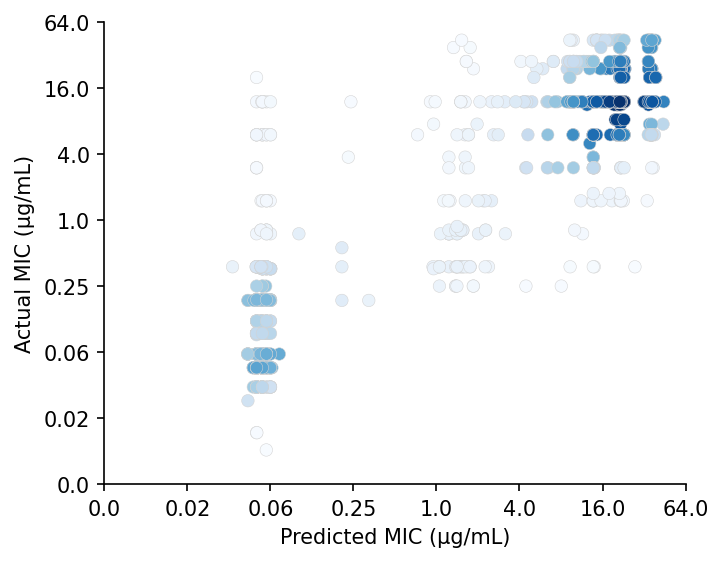

In [5]:
drug = "Rifampicin"
drug_abbr = "RIF"

RIF_CNN_predictions = pd.read_csv(f"{drug}/validation/CNN_predictions.csv")
RIF_CNN_predictions = plot_actual_predicted_MIC(RIF_CNN_predictions, df_rif_val, drug_abbr)

EA: 0.43314366998577525


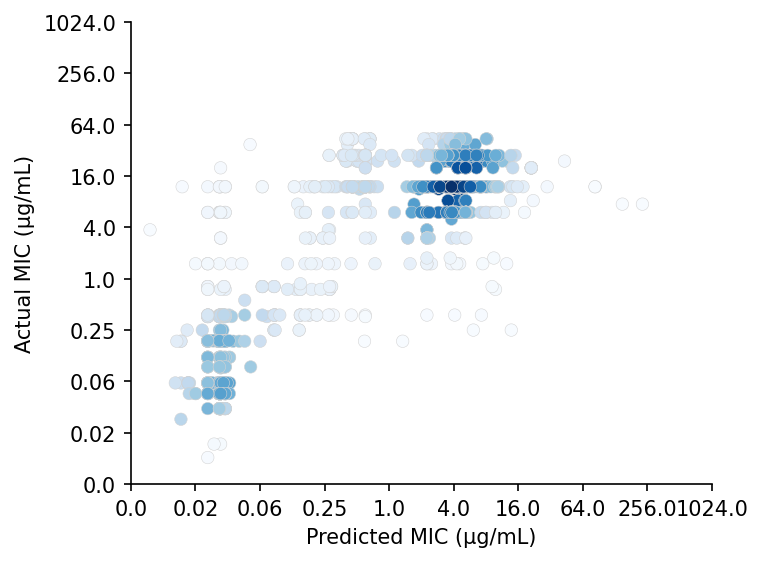

In [22]:
drug = "Rifampicin"
drug_abbr = "RIF"

RIF_Reg_predictions = pd.read_csv(f"{drug}/validation/Reg_predictions.csv")
RIF_Reg_predictions = plot_actual_predicted_MIC(RIF_Reg_predictions, df_rif_val, drug_abbr)

EA: 0.8053846153846154


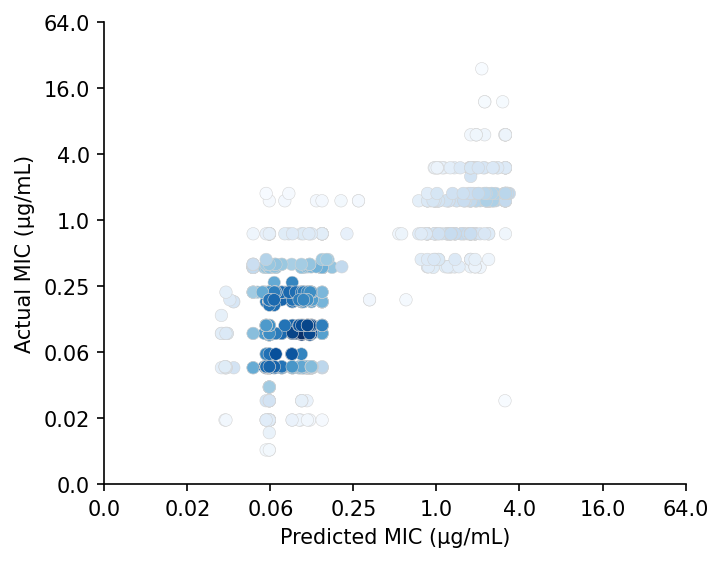

In [23]:
drug = "Moxifloxacin"
drug_abbr = "MXF"

MXF_CNN_predictions = pd.read_csv(f"{drug}/validation/CNN_predictions.csv")
MXF_CNN_predictions = plot_actual_predicted_MIC(MXF_CNN_predictions, df_mxf_val, drug_abbr)

EA: 0.703076923076923


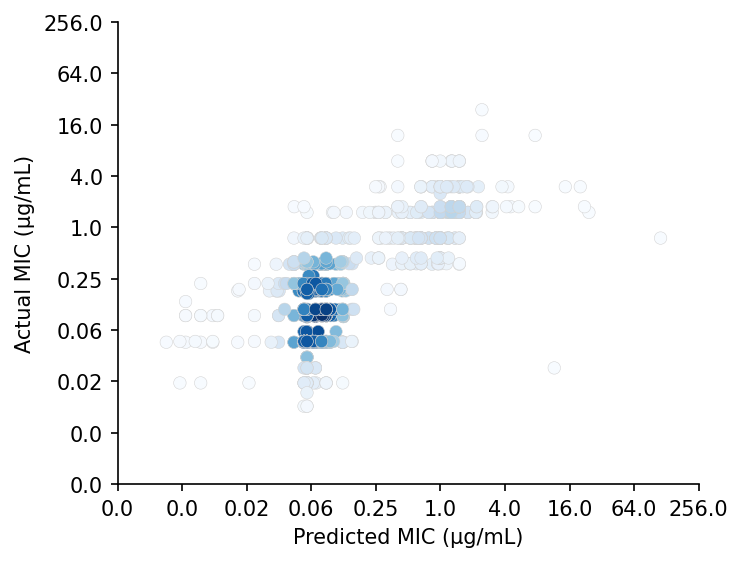

In [24]:
drug = "Moxifloxacin"
drug_abbr = "MXF"

MXF_Reg_predictions = pd.read_csv(f"{drug}/validation/Reg_predictions.csv")
MXF_Reg_predictions = plot_actual_predicted_MIC(MXF_Reg_predictions, df_mxf_val, drug_abbr)